In [181]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

import gpjax as gpx
import optax as ox
import paramax as px
import numpy as np

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, regularised_score
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import prediction_basis, nlpd_gp, nlpd_pro, crps_gp, crps_pro
from non_parametric_pro.data.uci import load_uci_regression_dataset
from non_parametric_pro.parameter_adaptation import parameter_adaptation, cross_validated_parameter_adaptation
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.util import run_inference_algorithm_with_burn_in, posterior_function_draws, predictive_moments

from non_parametric_pro.data.interpolation_gap import (
    make_interpolation_instance
)
from non_parametric_pro.data.huber import (
    make_huber_instance
)
from non_parametric_pro.data.matern_mismatch import (
    make_matern_mismatch_instance
)

from blackjax.util import run_inference_algorithm

from sklearn.preprocessing import StandardScaler
from scipy import stats

jax.config.update("jax_enable_x64", True)

In [182]:
def interpolation_gap_mask(x: jax.Array, gap_center: float, gap_width: float) -> jax.Array:
    """Boolean mask, True where `x` falls inside the gap (``|x - gap_center| <=
    gap_width / 2``) -- mirrors the other datasets' `*_region_mask` membership rule, for
    region-conditional evaluation (here: interpolation-gap vs. ordinary holdout)."""
    return jnp.abs(x - gap_center) <= gap_width / 2

def _plot_matern_mismatch_case(ax, data):
    """
    Plot one MaternMismatchCase: the single latent truth curve (drawn from the
    RBF/Matern-3/2 blend -- visibly more jagged as `matern_mix` grows) and the noisy
    observed points. No special coloring -- there's no hidden branch, censoring, or
    outlier label here, just a single well-defined function whose *smoothness class*
    is what's being tested, visible directly in how kinked the curve looks.
    """
    x_full = jnp.concatenate([data.x_train[:, 0], data.x_test[:, 0]])
    y_full = jnp.concatenate([data.y_truth_train[:, 0], data.y_truth_test[:, 0]])
    order = jnp.argsort(x_full)
    x_sorted, y_sorted = x_full[order], y_full[order]

    ax.plot(x_sorted, y_sorted, color="C0", linewidth=1.5)
    ax.scatter(data.x_train, data.y_train, color="black", s=8, zorder=3)
    ax.set_title(
        f"$\\ell$={data.ell:.2f}  $\\alpha$={data.alpha:.2f}  matern={data.matern_mix:.2f}",
        fontsize=9,
    )

def _plot_huber_case(ax, data):
    """
    Plot one HuberCase: the single latent truth curve and observed points, colored by
    the *true* (hidden) contamination indicator -- orange = drawn from the wide
    outlier-scale Gaussian, black = ordinary noise. Applied over the whole domain (no
    region), matching `heavy_tailed.py`'s final form -- gross errors aren't spatially
    correlated with x in the classical Huber model. Unlike `_plot_heavy_tailed_case`
    (which has to guess outliers via a residual threshold), this dataset actually
    generates a ground-truth contamination label, so we use it directly.
    """
    x_full = jnp.concatenate([data.x_train[:, 0], data.x_test[:, 0]])
    y_full = jnp.concatenate([data.y_truth_train[:, 0], data.y_truth_test[:, 0]])
    order = jnp.argsort(x_full)
    x_sorted, y_sorted = x_full[order], y_full[order]

    ax.plot(x_sorted, y_sorted, color="C0", linewidth=1.5)

    is_outlier = data.is_outlier_train
    ax.scatter(data.x_train[~is_outlier], data.y_train[~is_outlier], color="black", s=8, zorder=3)
    ax.scatter(data.x_train[is_outlier], data.y_train[is_outlier], color="C1", s=8, zorder=3)
    ax.set_title(
        f"$\\ell$={data.ell:.2f}  $\\alpha$={data.alpha:.2f}  $\\epsilon$={data.contamination_prob:.2f}",
        fontsize=9,
    )

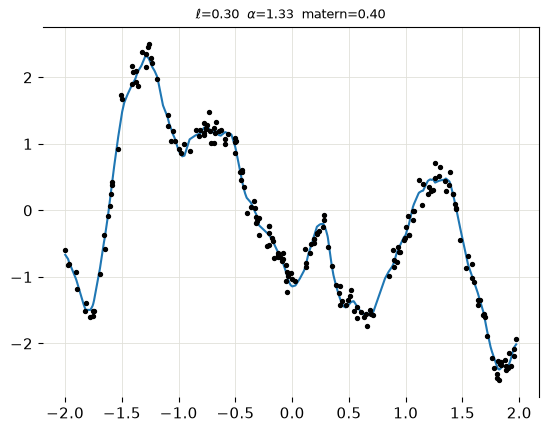

In [245]:
key = jr.PRNGKey(12)

example = make_matern_mismatch_instance(key, noise_std_frac=0.1, matern_mix=0.4)

x_train, y_train = example.x_train, example.y_train
x_test, y_test = example.x_test, example.y_test

idx = np.argsort(x_test.squeeze())
x_test = x_test[idx]
y_test = y_test[idx]

fig, ax = plt.subplots()
_plot_matern_mismatch_case(ax, example)


In [206]:
D = x_train.shape[1]

data = gpx.Dataset(X=x_train, y=y_train)
kernel = gpx.kernels.RBF(lengthscale=0.3)

prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

gp_posterior, _ = gpx.fit_scipy(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
)

gp_latent_train_dist = gp_posterior.predict(x_train, train_data=data)
gp_predictive_train_dist = gp_posterior.likelihood(gp_latent_train_dist)

gp_predictive_train_mean = gp_predictive_train_dist.mean
gp_predictive_train_std = jnp.sqrt(gp_predictive_train_dist.variance)

gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))

gp_latent_dist = gp_posterior.predict(x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

Optimization terminated successfully.
         Current function value: -52.080583
         Iterations: 11
         Function evaluations: 17
         Gradient evaluations: 17
GP Train NLPD: -0.730517552686477
GP Test NLPD: -0.5401400600855398


In [207]:
print("GP sigma", px.unwrap(gp_sigma))
print(px.unwrap(gp_kernel.lengthscale))
print(px.unwrap(gp_kernel.variance))

GP sigma 0.12469996444852137
0.13015613175010557
0.9456572438096434


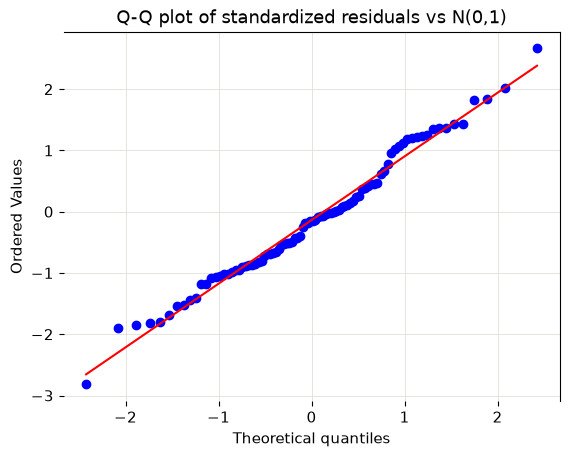

Shapiro-Wilk: 0.4591923838901613
Kolmogorov-Smirnov: 0.17373318704520924


In [208]:
residuals = (y_test.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

ks_stat, ks_pvalue = stats.kstest(residuals, "norm")

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)
print("Kolmogorov-Smirnov:", ks_pvalue)

In [230]:
num_particles = 60
sigma = gpx.parameters.SigmoidBounded(0.5, low=0.1, high=1.0)
lengthscale = gpx.parameters.SigmoidBounded(0.3, low=1.0e-3, high=1.0e3)
kernel = gpx.kernels.RBF(lengthscale=lengthscale)

pro_params = ProParameters(
    y=y_train,
    basis=None,
    step_size=0.0001,
    sigma=sigma,
    alpha=1.0,
)

adaptation = cross_validated_parameter_adaptation(
    ula,
    pro_logdensity_fn,
    pro_params,
    x_full=x_train,
    y_full=y_train,
    initial_kernel=kernel,
    num_folds=1,
    val_fraction=0.3,
    num_particles=num_particles,
    num_steps=20000,
    warmup_steps=1000,
    sigma_adapt_steps=600,
    kernel_adapt_steps=350,
    objective_fn=pro_logdensity_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(0.01),
    progress_bar=True,
    rng_key=key
) 

Running parameter adaptation


<div><progress max="20000" value="20000"></progress> 100.00% [20000/20000 00:00&lt;?]</div>

In [231]:
print(adaptation.sigma)
print(adaptation.kernel.lengthscale)
print(adaptation.kernel.variance)

0.11121493748822962
0.21421210403884708
1.4274292250011715


In [232]:
adapted_kernel = adaptation.kernel
adapted_sigma = adaptation.sigma

k = adapted_kernel.gram(x_train).as_matrix()
basis_full = jnp.linalg.cholesky(k + 1e-6 * jnp.eye(k.shape[0]))


In [235]:
pro_params = pro_params._replace(basis=basis_full, sigma=adapted_sigma, alpha=1.0, step_size=0.0001)
algorithm = parametric_ula(pro_logdensity_fn, pro_params)
num_steps = 50000

key, pos_key = jr.split(key)
initial_position = jr.normal(pos_key, (x_train.shape[0], num_particles))

key, sample_key = jr.split(key)
_, (states, info) = run_inference_algorithm_with_burn_in(
    rng_key=sample_key,
    inference_algorithm=algorithm,
    initial_position=initial_position,
    num_steps=num_steps,
    burn_ratio=0.9,
    progress_bar=True,
)

<div><progress max="45000" value="45000"></progress> 100.00% [45000/45000 00:00&lt;?]</div>

<div><progress max="5000" value="5000"></progress> 100.00% [5000/5000 00:00&lt;?]</div>

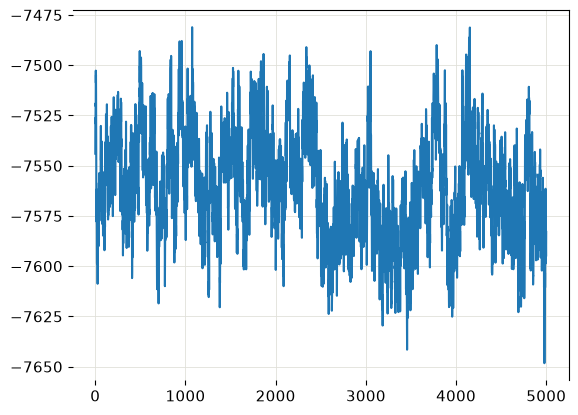

In [236]:
plt.plot(-info.score)
plt.show()

In [237]:
particles = states.position[::10]

test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_train, pro_params
)

print("PRO Train NLPD:", nlpd_pro(y_train, test_basis, test_cov, particles, parameters=pro_params))


test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

print("PRO Test NLPD:", nlpd_pro(y_test, test_basis, test_cov, particles, parameters=pro_params))
print("GP Train NLPD:", nlpd_gp(y_train, gp_predictive_train_mean, gp_predictive_train_std))
print("GP Test NLPD:", nlpd_gp(y_test, gp_predictive_mean, gp_predictive_std))

PRO Train NLPD: -0.6011302963025477
PRO Test NLPD: -0.3250472949372133
GP Train NLPD: -0.730517552686477
GP Test NLPD: -0.5401400600855398


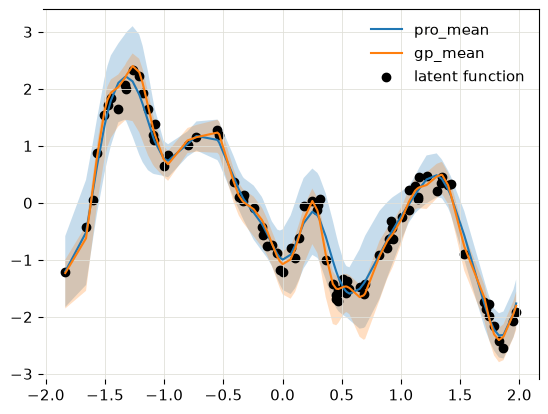

In [238]:
mean, std = predictive_moments(test_basis, particles, noise_std=adapted_sigma)

x_plot = x_test.squeeze()

plt.plot(x_plot, mean, label="pro_mean")
plt.plot(x_plot, gp_predictive_mean, label="gp_mean")
plt.fill_between(x_plot, mean - 1.64 * std, mean + 1.64 * std, alpha=0.25)
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.25)
plt.scatter(x_test.squeeze(), y_test.squeeze(), color="black", label="latent function")
plt.legend()
plt.show()

In [239]:
test_basis, test_cov = prediction_basis(
    adapted_kernel, x_train, x_test, pro_params
)

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    particles,
    num_draws=100,
    jitter=pro_params.jitter,
)

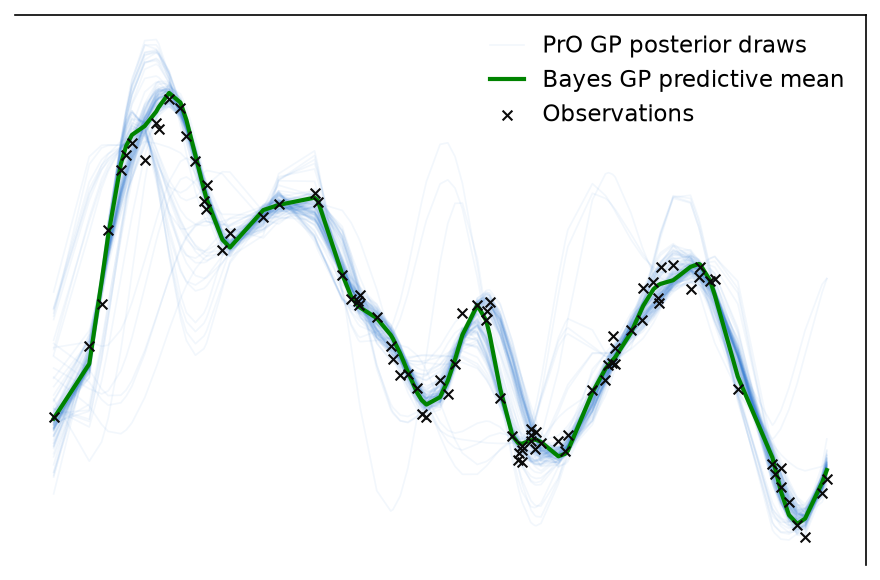

In [240]:

import numpy as np
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
})

draw_color = "#2a78d6"
mean_color = "#008300"
obs_color = "#0b0b0b"

order = np.argsort(x_test.squeeze())
x_sorted = x_test.squeeze()[order]
y_sorted = y_test.squeeze()[order]
mean_sorted = np.asarray(gp_predictive_mean).squeeze()[order]
draws_sorted = np.asarray(draws)[order]

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

ax.plot(x_sorted, draws_sorted[:, 0], color=draw_color, alpha=0.06, linewidth=0.8,
        label="PrO GP posterior draws", rasterized=True)
ax.plot(x_sorted, draws_sorted[:, 1:], color=draw_color, alpha=0.06, linewidth=0.8,
        rasterized=True)
ax.plot(x_sorted, mean_sorted, color=mean_color, linewidth=2.0,
        label="Bayes GP predictive mean")
ax.scatter(x_sorted, y_sorted, color=obs_color, marker="x", s=22, linewidths=1.0,
           label="Observations", zorder=5)

ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="best", handlelength=1.5)
fig.tight_layout()
plt.show()